In [2]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import pyproj
from pyproj import Transformer
from datetime import datetime, timedelta
import os, fnmatch, glob
import cmocean 
import rasterio
from rasterio.plot import show
import sys
import geopy.distance
import pandas as pd

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [3]:
from TrajectoryEvaluationTemp import StatisticalEvaluation


In [1]:
ls

 FirstTry.ipynb                     TrajectoryEvaluationTemp.ipynb
'Investigate a single buoy.ipynb'   TrajectoryEvaluationTemp.py
 SecondTry-.ipynb


In [ ]:
#Load OMB data
OMBraw = xr.open_mfdataset('/home/maltem/work/python/data/SvalMIZ2024/cruise/2024_KVS_deployment.nc')  

In [3]:
OMBtemp = xr.open_mfdataset('/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/updated_dataset_temp.nc')
OMBtemp1 = xr.open_mfdataset('/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_AIFS_ICON_AROMEArctic_ARPEGE.nc')

In [5]:
OMBtemp['T2M'][6,:,:,:]=OMBtemp1['T2M'][6,:,:,:]

In [7]:
OMBtemp.to_netcdf('newfile.nc')

Statistical evaluation of 33 buoys
Use of model:  MET-AROMEArctic
 -- choose model number  0
[-25 -20 -15 -10  -5   0]


/tmp/ipykernel_309719/914029925.py:83: RuntimeWarning: Mean of empty slice
  bias[lt] = np.nanmean(temp_mod - temp_obs)
/tmp/ipykernel_309719/914029925.py:84: RuntimeWarning: Mean of empty slice
  rmse[lt] = np.sqrt(np.nanmean((temp_obs - temp_mod) ** 2))
/tmp/ipykernel_309719/914029925.py:111: RuntimeWarning: Mean of empty slice
  bin_bias = np.nanmean(bin_temp_mod - bin_temp_obs)
/tmp/ipykernel_309719/914029925.py:112: RuntimeWarning: Mean of empty slice
  bin_mae  = np.nanmean(np.abs(bin_temp_mod - bin_temp_obs))
/tmp/ipykernel_309719/914029925.py:113: RuntimeWarning: Mean of empty slice
  bin_rmse = np.sqrt(np.nanmean((bin_temp_obs - bin_temp_mod) ** 2))


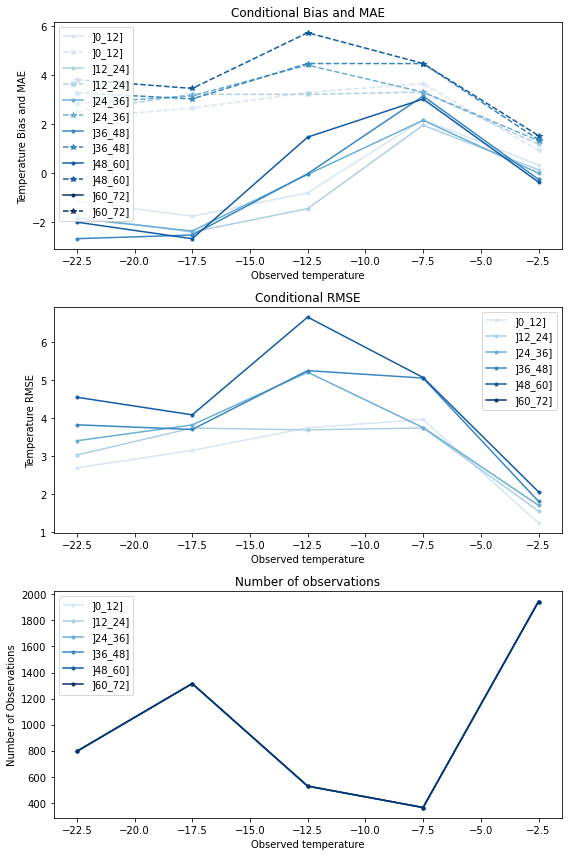

In [55]:
#### startdate = datetime.strptime('2024-04-04 00:00:00','%Y-%m-%d %H:%M:%S')
enddate   = datetime.strptime('2024-05-10 00:00:00','%Y-%m-%d %H:%M:%S')
ifiletemp     = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_AIFS_ICON_AROMEArctic.nc'
ifiledrift    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_TOPAZ_GOFS_RIOPS_NextSIM_ROMS00t_ROMS01t_MODIS_AMSR2_upd2.nc'

s1 = StatisticalEvaluation([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32],
                           'MET-AROMEArctic',startdate,enddate,[1,1],ifiledrift,ifiletemp)


#s1 = StatisticalEvaluation([32],'MET-AROMEArctic',startdate,enddate,[1,1],ifiledrift,ifiletemp)

## Little temporary fix:
OMBtemp = xr.open_mfdataset('/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_AIFS_ICON_AROMEArctic.nc')
OMBtemp1 = xr.open_mfdataset('/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_IFS_AIFS.nc')
OMBtemp['temp_flag_1m'] = (['tr_nr', 'time_ds'], OMBtemp1.temp_flag_1m.values)
OMBtemp['temp_flag_cons'] = (['tr_nr', 'time_ds'], OMBtemp1.temp_flag_cons.values)
OMBtemp['T2M'][4,:,:,:]=OMBtemp1['T2M'][4,:,:,:]
s1.OMBtemp   = OMBtemp
s1.info()
s1.flag_values(rad_threshold=80)


#s1.teval_cond_err(-0.35, 0.3, 0.05,leadno=2,cond='sicerr',doplot=True)
s1.teval_cond_err(-30, 5, 5,leadno=6,cond='temp',doplot=True)
#s1.teval_cond_err(-0., 1.2, 0.2,leadno=5,cond='sic',doplot=True)

In [68]:
startdate = datetime.strptime('2024-04-04 00:00:00','%Y-%m-%d %H:%M:%S')
enddate   = datetime.strptime('2024-05-10 00:00:00','%Y-%m-%d %H:%M:%S')
ifiletemp     = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_AIFS_ICON_AROMEArctic.nc'
ifiledrift    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_TOPAZ_GOFS_RIOPS_NextSIM_ROMS00t_ROMS01t_MODIS_AMSR2_upd2.nc'
i=0

biasAll  = np.zeros([4,8])

rmseALL  = np.zeros([4,8])

modelALL = ['MET-AROMEArctic', 'DWD-ICON', 'ECMWF-IFS', 'ECMWF-AIFS']
for model in modelALL[0:4]:
    print(model)
    
    #s1 = StatisticalEvaluation([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32],
    #                       model,startdate,enddate,[1,1],ifiledrift,ifiletemp)
    s1 = StatisticalEvaluation([28],
                           model,startdate,enddate,[1,1],ifiledrift,ifiletemp)
    
    # Little temporary fix:
    OMBtemp = xr.open_mfdataset('/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_AIFS_ICON_AROMEArctic.nc')
    OMBtemp1 = xr.open_mfdataset('/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_temp_IFS_AIFS.nc')
    OMBtemp['temp_flag_1m'] = (['tr_nr', 'time_ds'], OMBtemp1.temp_flag_1m.values)
    OMBtemp['temp_flag_cons'] = (['tr_nr', 'time_ds'], OMBtemp1.temp_flag_cons.values)
    OMBtemp['T2M'][4,:,:,:]=OMBtemp1['T2M'][4,:,:,:]
    s1.OMBtemp   = OMBtemp
    #----------------------
    #s1.info()
    s1.flag_values(rad_threshold=80)
    s1.teval_cond_err(-18, 5, 2,leadno=8,cond='temp',doplot=False)
    biasAll[i,:]=s1.bias
    rmseALL[i,:]=s1.rmse
    i=i+1

MET-AROMEArctic
 -- choose model number  0
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]


/tmp/ipykernel_309719/914029925.py:83: RuntimeWarning: Mean of empty slice
  bias[lt] = np.nanmean(temp_mod - temp_obs)
/tmp/ipykernel_309719/914029925.py:84: RuntimeWarning: Mean of empty slice
  rmse[lt] = np.sqrt(np.nanmean((temp_obs - temp_mod) ** 2))
/tmp/ipykernel_309719/914029925.py:111: RuntimeWarning: Mean of empty slice
  bin_bias = np.nanmean(bin_temp_mod - bin_temp_obs)
/tmp/ipykernel_309719/914029925.py:112: RuntimeWarning: Mean of empty slice
  bin_mae  = np.nanmean(np.abs(bin_temp_mod - bin_temp_obs))
/tmp/ipykernel_309719/914029925.py:113: RuntimeWarning: Mean of empty slice
  bin_rmse = np.sqrt(np.nanmean((bin_temp_obs - bin_temp_mod) ** 2))


DWD-ICON
 -- choose model number  3
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]


/tmp/ipykernel_309719/914029925.py:111: RuntimeWarning: Mean of empty slice
  bin_bias = np.nanmean(bin_temp_mod - bin_temp_obs)
/tmp/ipykernel_309719/914029925.py:112: RuntimeWarning: Mean of empty slice
  bin_mae  = np.nanmean(np.abs(bin_temp_mod - bin_temp_obs))
/tmp/ipykernel_309719/914029925.py:113: RuntimeWarning: Mean of empty slice
  bin_rmse = np.sqrt(np.nanmean((bin_temp_obs - bin_temp_mod) ** 2))
/tmp/ipykernel_309719/914029925.py:83: RuntimeWarning: Mean of empty slice
  bias[lt] = np.nanmean(temp_mod - temp_obs)
/tmp/ipykernel_309719/914029925.py:84: RuntimeWarning: Mean of empty slice
  rmse[lt] = np.sqrt(np.nanmean((temp_obs - temp_mod) ** 2))


ECMWF-IFS
 -- choose model number  4
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]


/tmp/ipykernel_309719/914029925.py:111: RuntimeWarning: Mean of empty slice
  bin_bias = np.nanmean(bin_temp_mod - bin_temp_obs)
/tmp/ipykernel_309719/914029925.py:112: RuntimeWarning: Mean of empty slice
  bin_mae  = np.nanmean(np.abs(bin_temp_mod - bin_temp_obs))
/tmp/ipykernel_309719/914029925.py:113: RuntimeWarning: Mean of empty slice
  bin_rmse = np.sqrt(np.nanmean((bin_temp_obs - bin_temp_mod) ** 2))
/tmp/ipykernel_309719/914029925.py:111: RuntimeWarning: Mean of empty slice
  bin_bias = np.nanmean(bin_temp_mod - bin_temp_obs)
/tmp/ipykernel_309719/914029925.py:112: RuntimeWarning: Mean of empty slice
  bin_mae  = np.nanmean(np.abs(bin_temp_mod - bin_temp_obs))
/tmp/ipykernel_309719/914029925.py:113: RuntimeWarning: Mean of empty slice
  bin_rmse = np.sqrt(np.nanmean((bin_temp_obs - bin_temp_mod) ** 2))


ECMWF-AIFS
 -- choose model number  5
[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4]


/tmp/ipykernel_309719/4100464536.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(s1.OMBtemp.lt_int.values)
/tmp/ipykernel_309719/4100464536.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(s1.OMBtemp.lt_int.values)


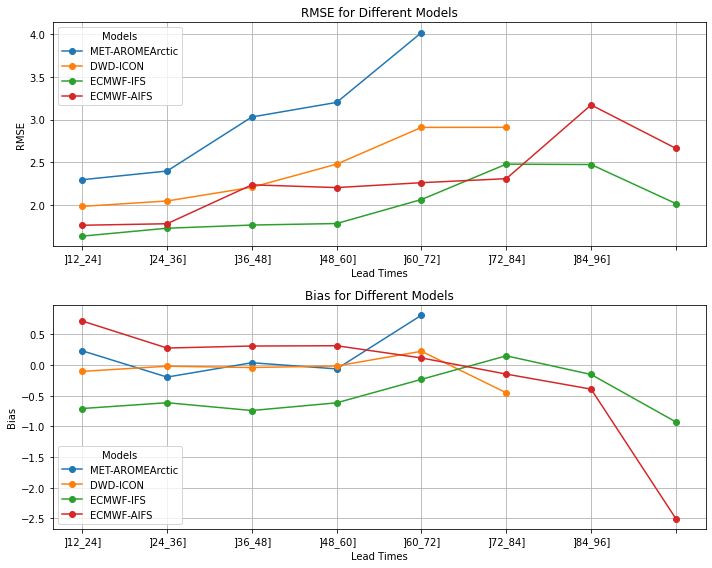

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data (replace with your actual rmseALL and biasALL arrays)
# Example: rmseALL and biasAll from your code
#rmseALL = np.random.rand(4, 8) * 10  # Random data as example
#biasAll = np.random.rand(4, 8) * 5   # Random data as example

# Define the model names and other labels for the plots
model_names = ['MET-AROMEArctic', 'DWD-ICON', 'ECMWF-IFS', 'ECMWF-AIFS']
time_steps = np.arange(0, 8)  # Assuming you have 8 time steps or evaluations

# Create a figure with two subplots (one for RMSE and one for Bias)
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Loop over models
for i, model in enumerate(model_names):
    # Plot RMSE for each model on the first subplot
    ax[0].plot(time_steps, rmseALL[i, :], label=model, marker='o')
    
    # Plot Bias for each model on the second subplot
    ax[1].plot(time_steps, biasAll[i, :], label=model, marker='o')

# First subplot: RMSE
ax[0].set_title('RMSE for Different Models')
ax[0].set_xlabel('Lead Times')
ax[0].set_ylabel('RMSE')
ax[0].legend(title="Models")
ax[0].grid(True)
ax[0].set_xticklabels(s1.OMBtemp.lt_int.values)

# Second subplot: Bias
ax[1].set_title('Bias for Different Models')
ax[1].set_xlabel('Lead Times')
ax[1].set_ylabel('Bias')
ax[1].legend(title="Models")
ax[1].grid(True)
ax[1].set_xticklabels(s1.OMBtemp.lt_int.values)
# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
##### OMBtemp = xr.open_mfdataset('/home/maltem/work/python/SvalMIZ2024/data/dataset_temp_IFS_AIFS.nc')
fig, ax = plt.subplots(figsize=(8, 6),nrows=3,ncols=1)
buoyno = 32

time_ds = s1.OMBtemp.time_ds.values  # Ensure time_ds is a NumPy array
time_min, time_max = np.min(time_ds), np.max(time_ds)


temp_1m         = s1.OMBtemp.temp_1m_calibrated[buoyno,:].values
temp_1m_flagged = s1.OMBtemp.temp_1m_calibrated[buoyno,:].values
temp_1m_flagged[s1.OMBtemp.temp_flag[buoyno,:].values==1]=np.nan

ax[1].plot(s1.OMBtemp.time_ds,temp_1m,marker='.',linewidth=0.2,color='grey',alpha=0.3)

ax[1].plot(s1.OMBtemp.time_ds,temp_1m_flagged,marker='.',linewidth=0.2,color='orange',alpha=0.6)

for axis in ax:
    axis.set_xlim([time_min+np.timedelta64(10, 'D'), time_max-np.timedelta64(24, 'D')])
    
print(np.sqrt(np.nanmean((temp_1m_flagged-OMBtemp.T2M[0,0,buoyno,:])**2)))